# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


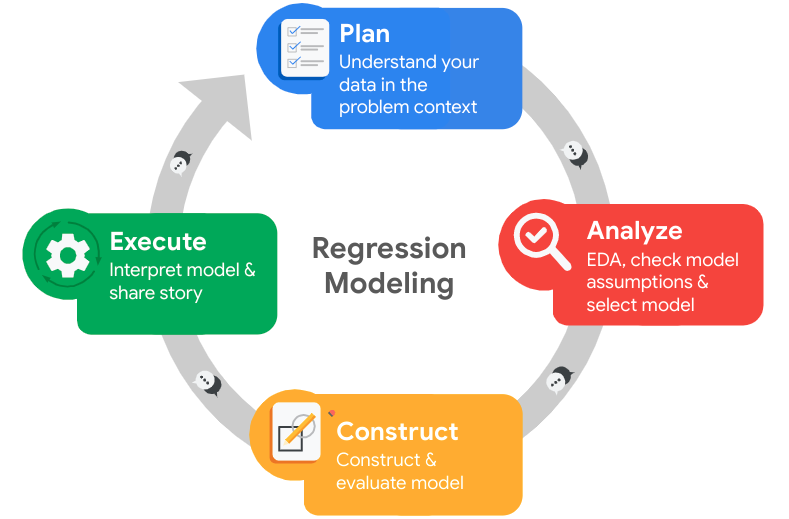

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

from xgboost import XGBClassifier, plot_importance

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [6]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns = {'satisfaction_level': 'Satisfaction_Level', 'last_evaluation': 'Last_Evaluation',
                            'number_project': 'Number_of_Projects', 'average_montly_hours': 'Avg_Monthly_Hrs', 
                            'time_spend_company':'Time_Spent_Company', 'Work_accident': 'Work_Accident', 
                            'left':'Left_Company', 'promotion_last_5years': 'Promotion_Last_5yr', 'salary':'Salary'})

# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['Satisfaction_Level', 'Last_Evaluation', 'Number_of_Projects',
       'Avg_Monthly_Hrs', 'Time_Spent_Company', 'Work_Accident',
       'Left_Company', 'Promotion_Last_5yr', 'Department', 'Salary'],
      dtype='str')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

Satisfaction_Level    0
Last_Evaluation       0
Number_of_Projects    0
Avg_Monthly_Hrs       0
Time_Spent_Company    0
Work_Accident         0
Left_Company          0
Promotion_Last_5yr    0
Department            0
Salary                0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

np.int64(3008)

In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated(keep=False)].sort_values(by='Last_Evaluation')

,Satisfaction_Level,Last_Evaluation,Number_of_Projects,Avg_Monthly_Hrs,Time_Spent_Company,Work_Accident,Left_Company,Promotion_Last_5yr,Department,Salary
11168,0.17,0.36,6,191,2,0,0,0,product_mng,medium
11119,0.19,0.36,3,167,5,0,0,0,sales,low
11500,0.49,0.36,2,192,3,0,0,0,sales,low
13711,0.49,0.36,2,192,3,0,0,0,sales,low
13330,0.19,0.36,3,167,5,0,0,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14152,0.58,1.00,4,220,10,0,0,0,marketing,medium
718,0.91,1.00,5,244,6,0,1,0,hr,low
719,0.80,1.00,5,260,5,0,1,0,hr,low
14959,0.59,1.00,2,155,5,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df0 = df0.drop_duplicates()

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df0.head()

,Satisfaction_Level,Last_Evaluation,Number_of_Projects,Avg_Monthly_Hrs,Time_Spent_Company,Work_Accident,Left_Company,Promotion_Last_5yr,Department,Salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

<Axes: ylabel='Time_Spent_Company'>

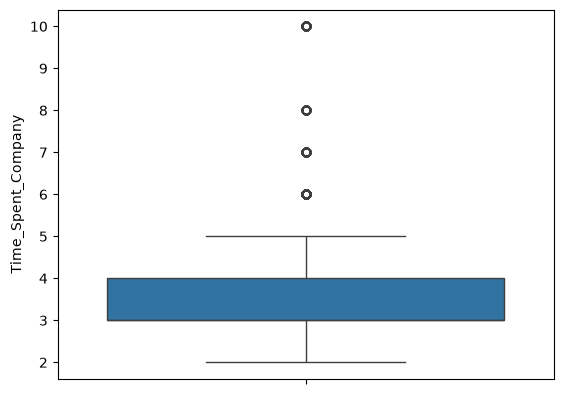

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
df0.Time_Spent_Company.describe()
sns.boxplot(data=df0['Time_Spent_Company'], showfliers=True)

In [12]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###

dfouts = df0[(df0.Time_Spent_Company > 5)]
dfouts.shape
dfouts

,Satisfaction_Level,Last_Evaluation,Number_of_Projects,Avg_Monthly_Hrs,Time_Spent_Company,Work_Accident,Left_Company,Promotion_Last_5yr,Department,Salary
1,0.80,0.86,5,262,6,0,1,0,sales,medium
17,0.78,0.99,4,255,6,0,1,0,sales,low
34,0.84,0.87,4,246,6,0,1,0,hr,low
47,0.57,0.70,3,273,6,0,1,0,support,low
67,0.90,0.98,4,264,6,0,1,0,product_mng,medium
...,...,...,...,...,...,...,...,...,...,...
11994,0.22,0.94,3,193,10,0,0,1,management,high
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [13]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
df0.Left_Company.value_counts()
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
df0.Left_Company.value_counts(normalize=True)

Left_Company
0    0.833959
1    0.166041
Name: proportion, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

<Axes: xlabel='Satisfaction_Level', ylabel='Count'>

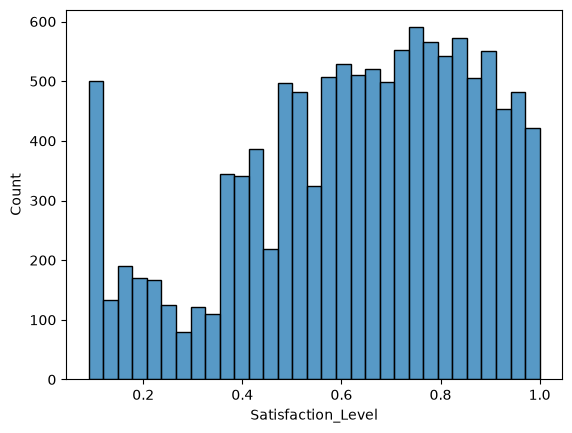

In [14]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.histplot(df0.Satisfaction_Level)

<Axes: xlabel='Last_Evaluation', ylabel='Count'>

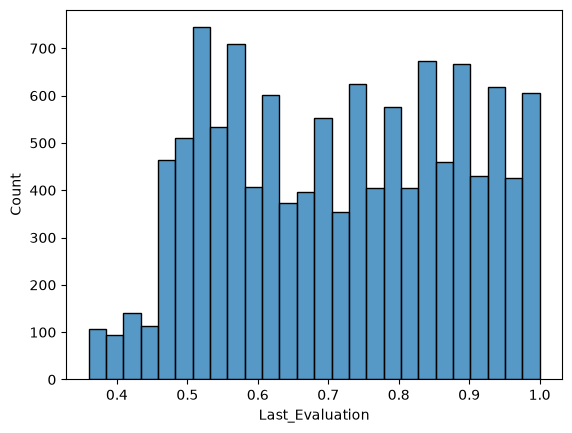

In [15]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.histplot(df0.Last_Evaluation)

<Axes: xlabel='Avg_Monthly_Hrs', ylabel='Count'>

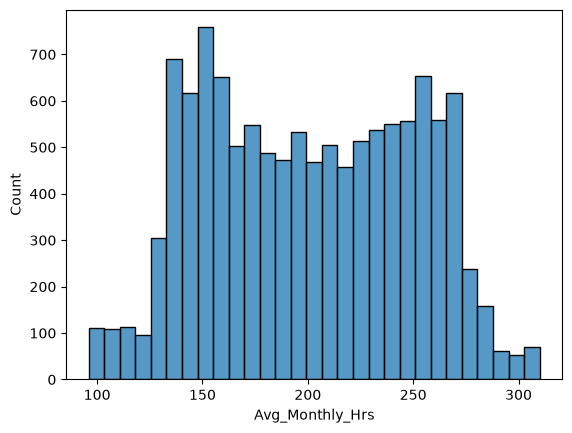

In [16]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.histplot(df0.Avg_Monthly_Hrs)

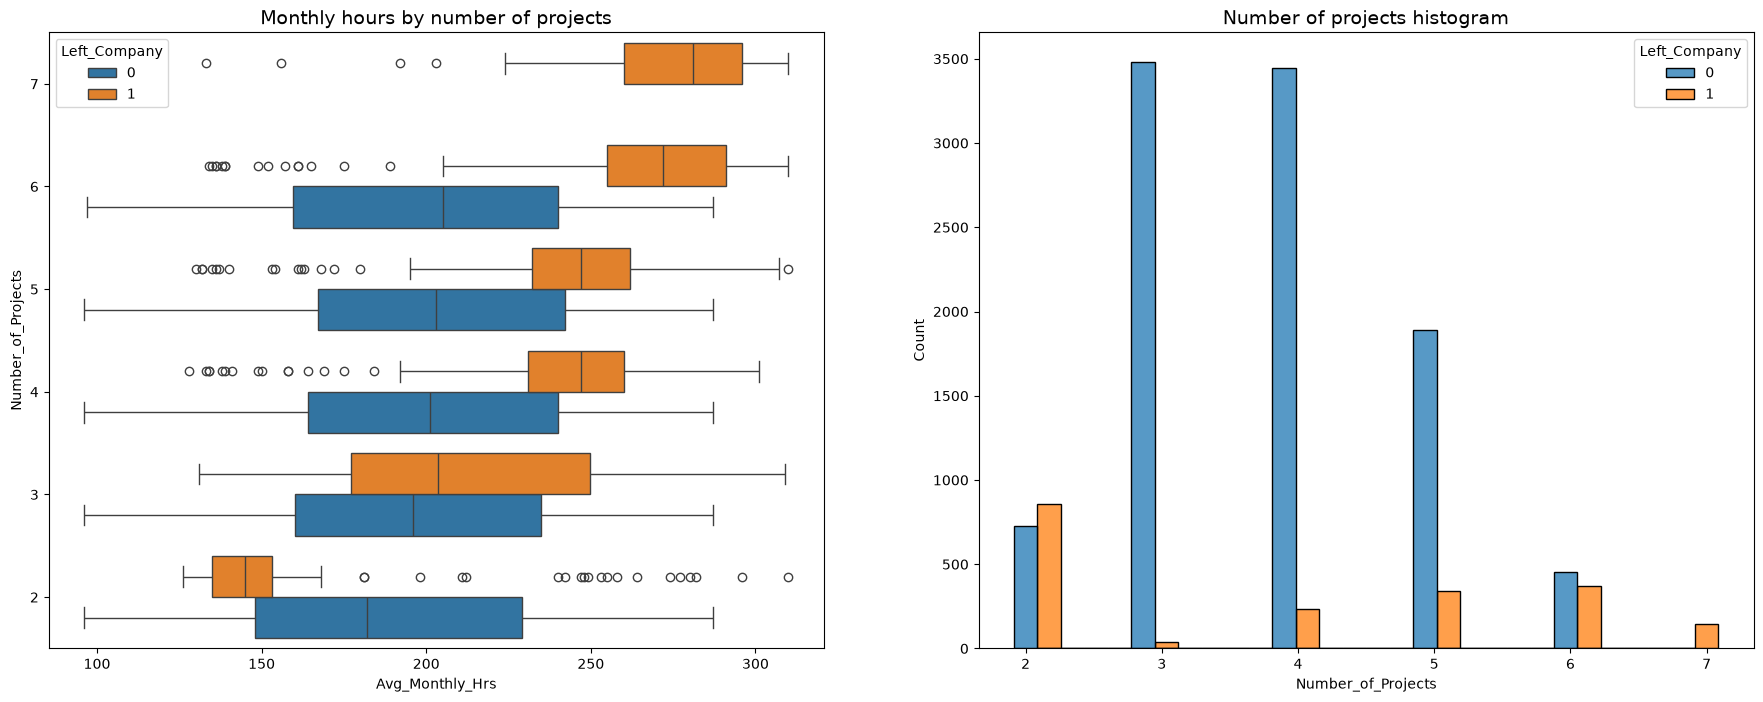

In [18]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# boxplot of average monthly hours distributions for number of projects, stayed vs left
sns.boxplot(data=df0, x='Avg_Monthly_Hrs', y='Number_of_Projects', hue='Left_Company', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# histogram of distribution of number of projects, stayed vs left
tenure_stay = df0[df0['Left_Company']==0]['Number_of_Projects']
tenure_left = df0[df0['Left_Company']==1]['Number_of_Projects']
sns.histplot(data=df0, x='Number_of_Projects', hue='Left_Company', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')


plt.show()

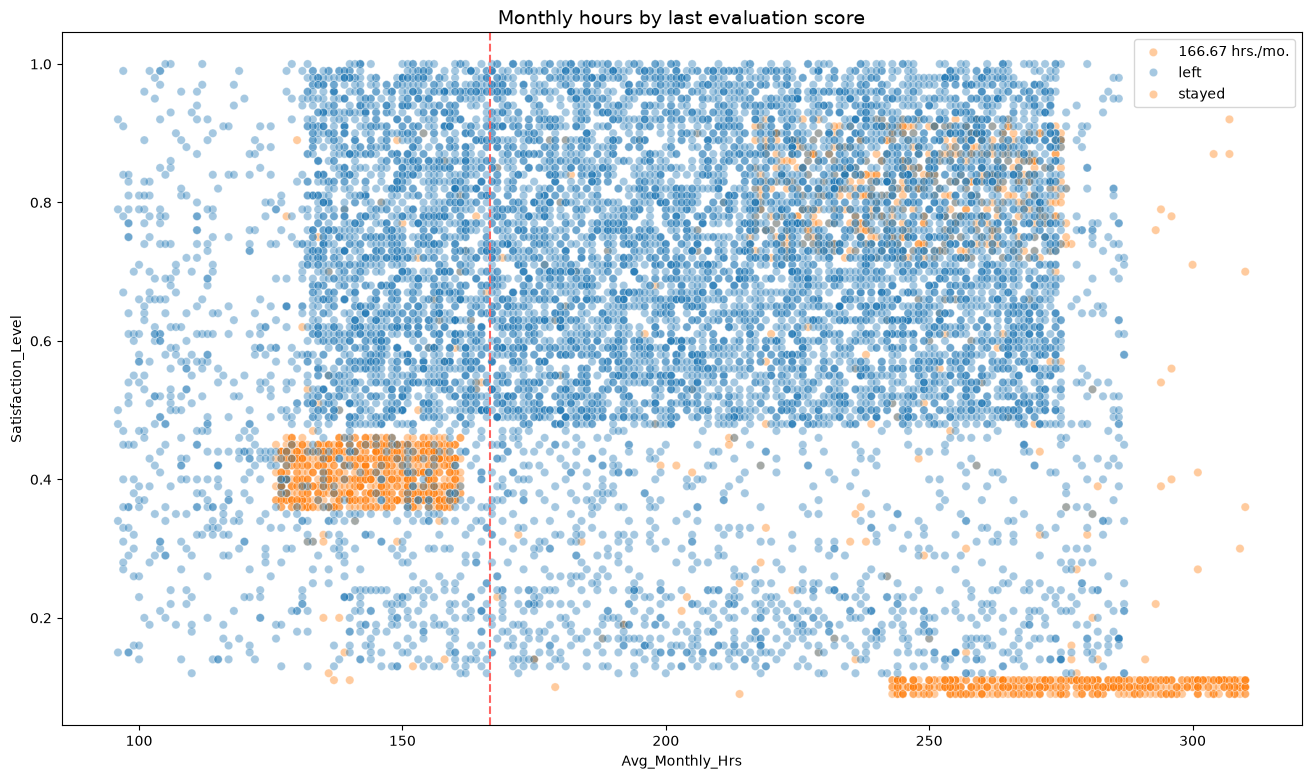

In [20]:
# scatterplot of average monthly hours and satisfaction level, stayed vs left
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df0, x='Avg_Monthly_Hrs', y='Satisfaction_Level', hue='Left_Company', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

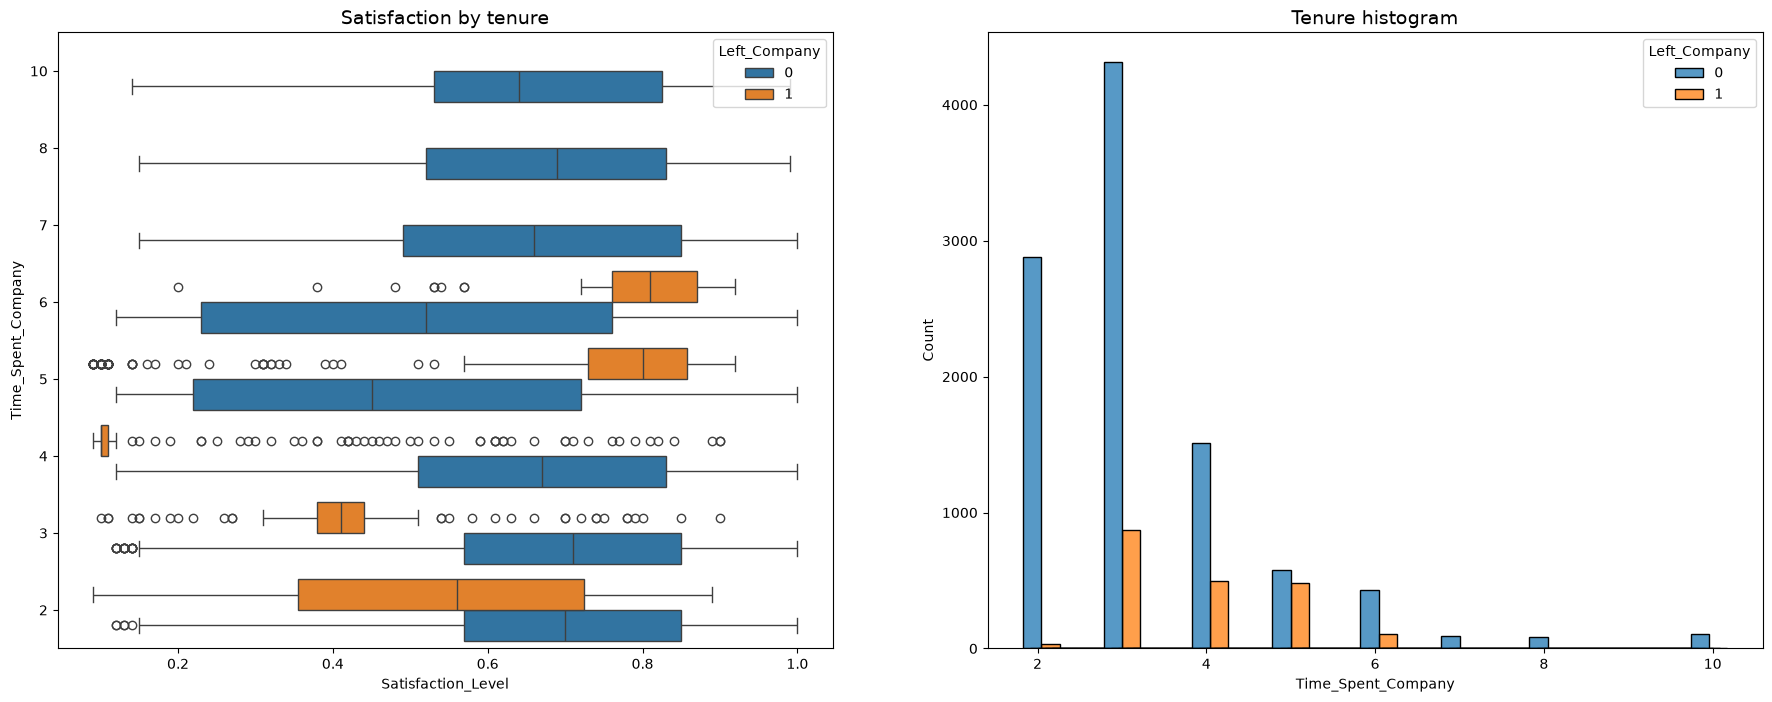

In [21]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# boxplot of distributions of satisfaction level by tenure, stayed vs left
sns.boxplot(data=df0, x='Satisfaction_Level', y='Time_Spent_Company', hue='Left_Company', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

# histogram showing distribution of tenure, stayed vs left
tenure_stay = df0[df0['Left_Company']==0]['Time_Spent_Company']
tenure_left = df0[df0['Left_Company']==1]['Time_Spent_Company']
sns.histplot(data=df0, x='Time_Spent_Company', hue='Left_Company', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

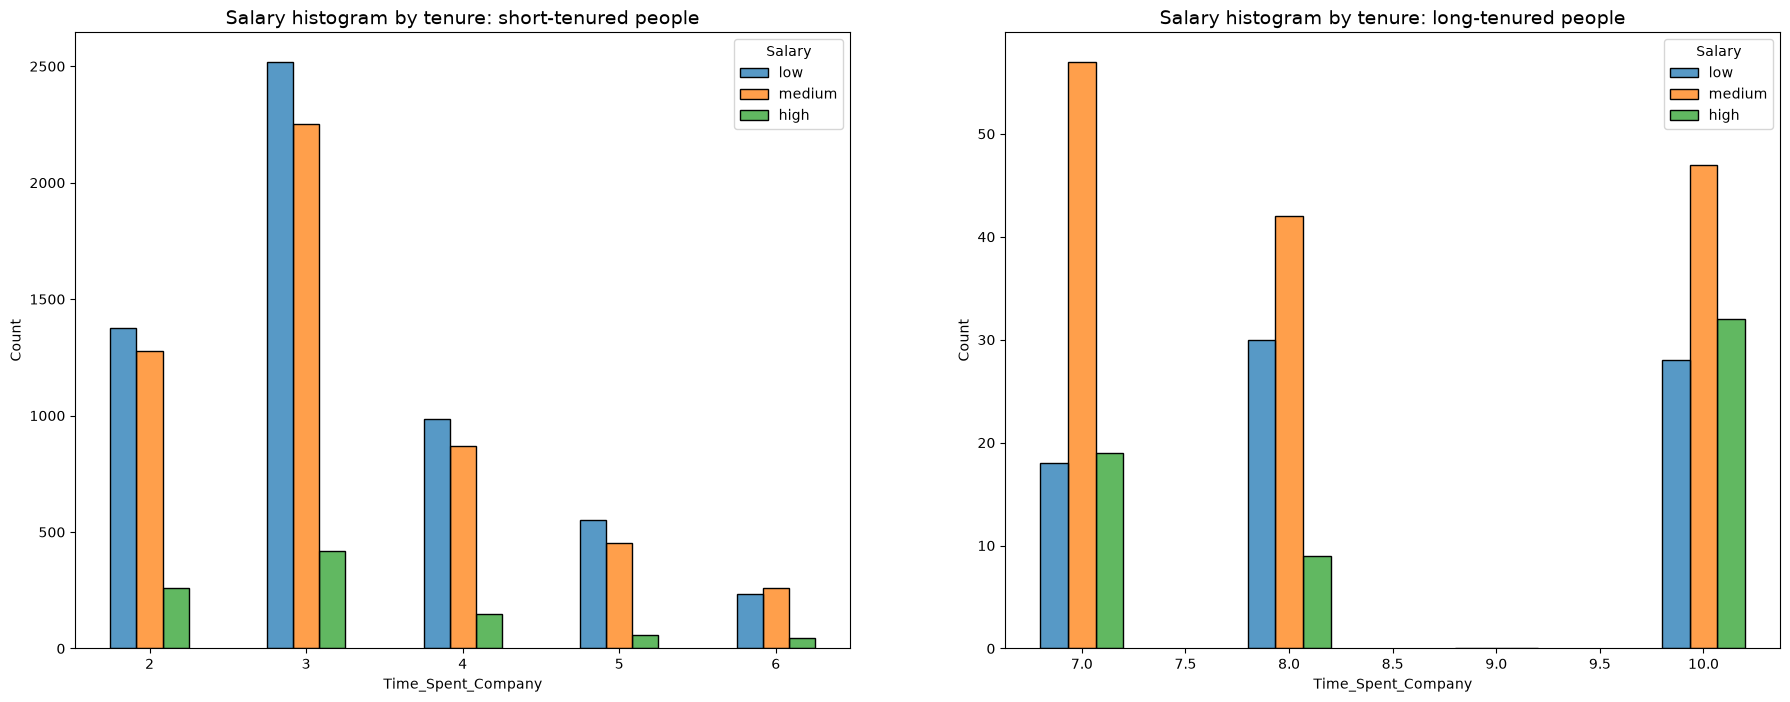

In [22]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))


tenure_short = df0[df0['Time_Spent_Company'] < 7]

tenure_long = df0[df0['Time_Spent_Company'] > 6]

# short-tenured histogram
sns.histplot(data=tenure_short, x='Time_Spent_Company', hue='Salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

# long-tenured histogram
sns.histplot(data=tenure_long, x='Time_Spent_Company', hue='Salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

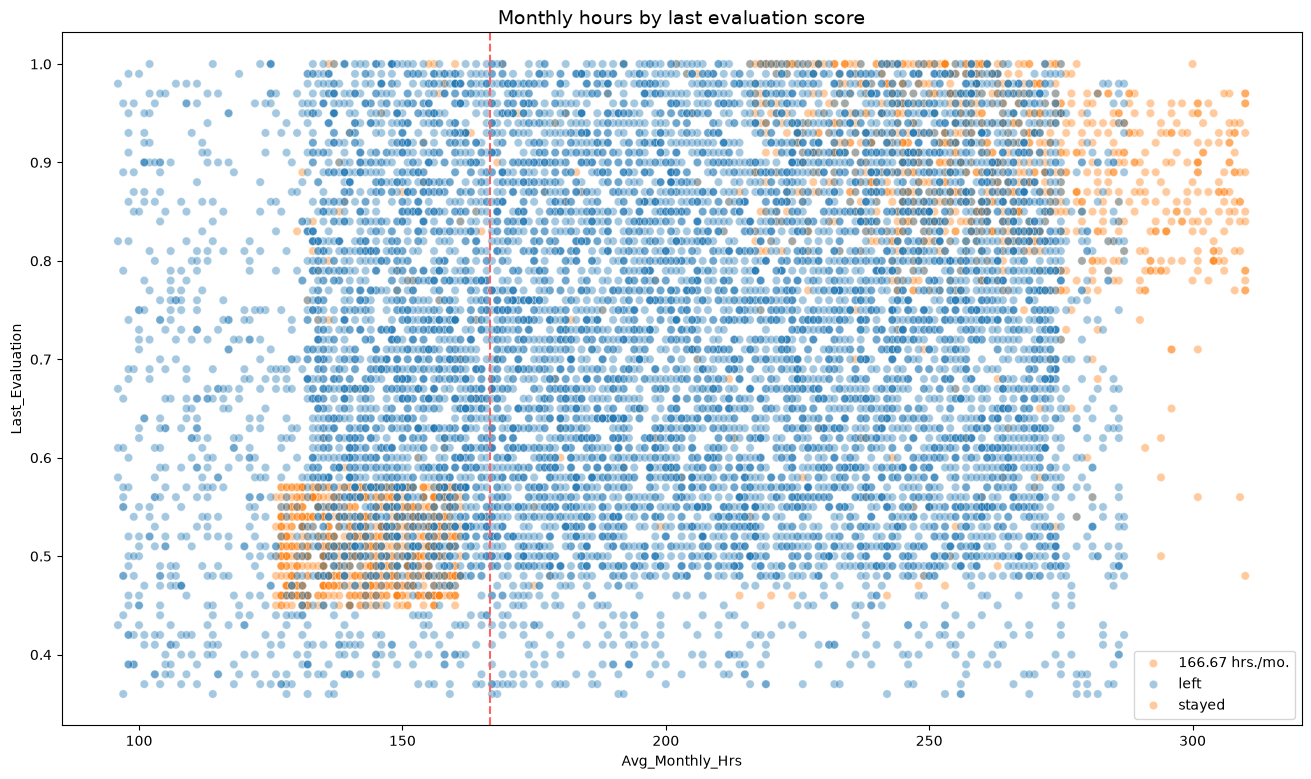

In [23]:

# scatterplot of average monthly hours vs last evaluation
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df0, x='Avg_Monthly_Hrs', y='Last_Evaluation', hue='Left_Company', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

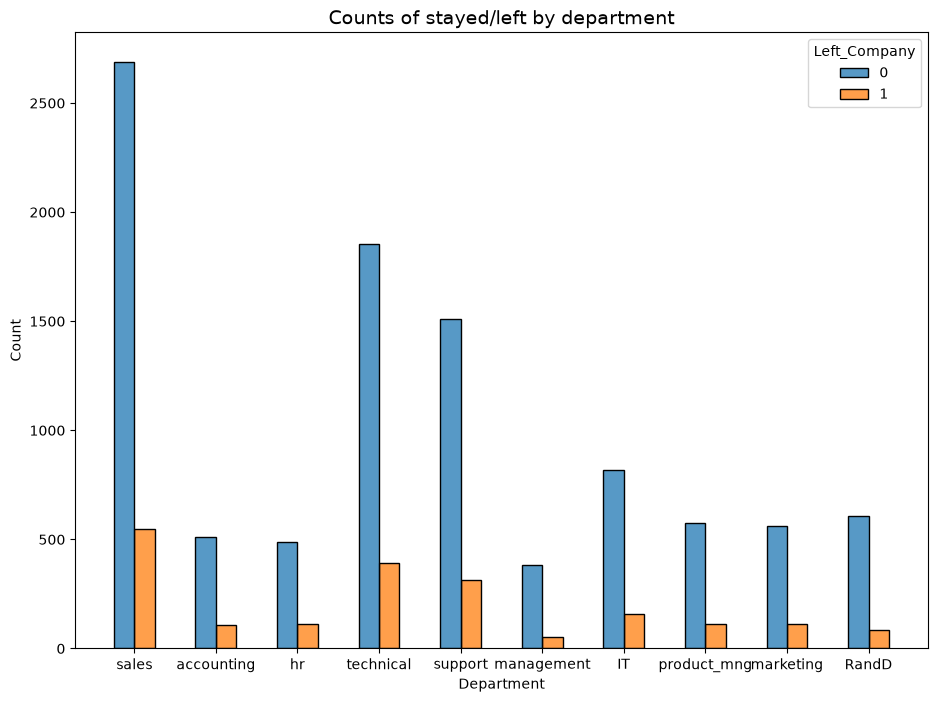

In [25]:
# stacked histogram of department distribution of left vs stayed
plt.figure(figsize=(11,8))
sns.histplot(data=df0, x='Department', hue='Left_Company', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks()
plt.title('Counts of stayed/left by department', fontsize=14);


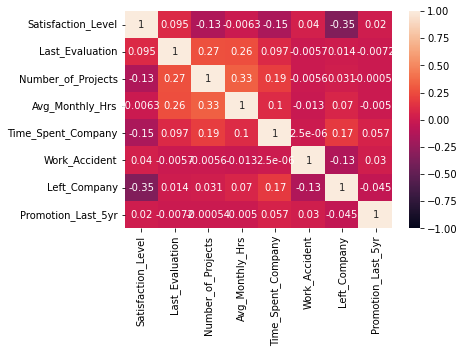

In [18]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.heatmap(df0.corr(method = 'pearson'), vmin= -1, vmax =1, annot=True)

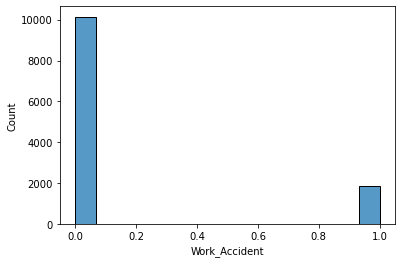

In [19]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.histplot(df0.Work_Accident)

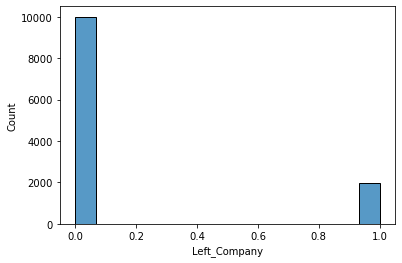

In [20]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.histplot(df0.Left_Company)

In [21]:
# Create a plot as needed
### YOUR CODE HERE ###


SyntaxError: invalid syntax (<ipython-input-21-3c9ebf727399>, line 3)

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

Using a heatmap plot showed the variables with the highest absolute value of correlation with leaving the company were satisfaction level, time spent with the company, and whether the employee was involved in a work accident. These variables appear to be the strongest predictors of an employee exit however most correlation coefficients were still fairly small. 
Also the examining of distributions in regards to the continuous data variables showed fairly normal distributions with some skewing slightly to the right. Skewed data doesn't work the best with logistic regression so other models may need to be considered.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

The extreme outliers in the time spent with the company column may influence model performance so it might be beneficial to drop the highest values to improve predictive power. 
One noteworthy observation is that most of the observations that left the company all seemed to be in the same index range and since that is a minority class it should be much more spread out.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

[Double-click to enter your responses here.]

The model will be used to predict a binary outcome variable and is thus a classification model

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

Since there are many outliers as well as slightly skewed distributions, ensemble learning models may be the most effective in addition to decision tree models.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [22]:
### YOUR CODE HERE ###
df = df0[df0.Time_Spent_Company < 10]
df.Time_Spent_Company.value_counts()
df0.Time_Spent_Company.value_counts()

3     5190
2     2910
4     2005
5     1062
6      542
10     107
7       94
8       81
Name: Time_Spent_Company, dtype: int64

In [23]:
x = df.drop(columns='Left_Company')
x= pd.get_dummies(x)
y = df.Left_Company
x.head()
y.head()
y.loc[1970: 2000]
x.head()

,Satisfaction_Level,Last_Evaluation,Number_of_Projects,Avg_Monthly_Hrs,Time_Spent_Company,Work_Accident,Promotion_Last_5yr,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,Salary_high,Salary_low,Salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [24]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state = 55)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=55)

In [25]:
rf = RandomForestClassifier(random_state=55)
scoring = ['accuracy', 'precision', 'recall', 'f1']
rfcv_params= {'n_estimators': [50,100,150,300], 
              'max_depth': [4,6,8,None], 
              'min_samples_leaf': [5,10,15], 
              'max_features': [3,6,None]}

In [26]:
rf_cv = GridSearchCV(rf, rfcv_params, cv=5, refit='recall', n_jobs=-1, verbose=1)

In [61]:
rf_cv.fit(x_tr, y_tr)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   46.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 720 out of 720 | elapsed:  6.1min finished


GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=55,
                                  

In [62]:
rf_cv.best_score_

0.9798036465638148

In [63]:
rf_cv.best_params_

{'max_depth': 8,
 'max_features': None,
 'min_samples_leaf': 5,
 'n_estimators': 50}

In [27]:
best_rf = RandomForestClassifier(max_depth = 8, max_features= None, min_samples_leaf= 5, n_estimators = 50, random_state=55)

In [28]:
best_rf.fit(x_tr, y_tr)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=8, max_features=None,
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=5, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=50,
                       n_jobs=None, oob_score=False, random_state=55, verbose=0,
                       warm_start=False)

In [29]:
rfy_pred= best_rf.predict(x_val)
rf_acc= metrics.accuracy_score(y_val, rfy_pred)
rf_recall=metrics.recall_score(y_val, rfy_pred)
rf_precision= metrics.precision_score(y_val, rfy_pred)
rf_f1 = metrics.f1_score(y_val, rfy_pred)
rf_acc, rf_recall, rf_precision, rf_f1

(0.9819099705511148, 0.9116161616161617, 0.978319783197832, 0.9437908496732026)

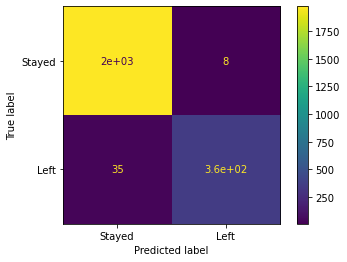

In [30]:
cm= metrics.confusion_matrix(y_val, rfy_pred, labels=best_rf.classes_)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels = ['Stayed', 'Left'])
disp.plot()


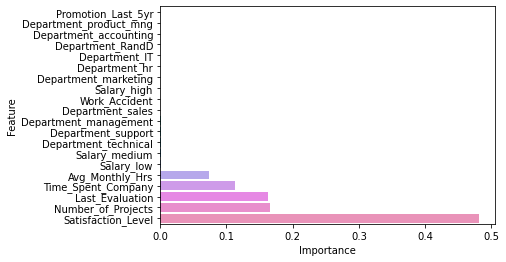

In [31]:
best_rf.feature_importances_
rfimp = pd.DataFrame({'Feature': x.columns, 'Importance': best_rf.feature_importances_}).sort_values('Importance')
sns.barplot(data= rfimp, x='Importance', y='Feature')

In [43]:
xgb = XGBClassifier(objective = 'binary:logistic', random_state=55)
xgbcv_params={'max_depth': [4,6,8,None],
              'min_child_weight':[5,10,15], 
              'n_estimators':[50,100,150,300], 
              'learning_rate':[0.1,0.2,0.3], 
              'colsample_bytree':[3,6,None]}

In [44]:
xgb_cv = GridSearchCV(xgb, xgbcv_params, scoring=scoring, cv=5, refit='recall', n_jobs =-1, verbose=1)

In [47]:
xgb_cv.fit(x_tr,y_tr)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 1408 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 1954 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done 2160 out of 2160 | elapsed:  9.3min finished


GridSearchCV(cv=5, error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max...
                                     predictor=None, random_state=55,
                                     reg_alpha=None, ...),
             iid='deprecated', n_jobs=-1,
             param_grid={'colsample_bytree': [3, 6, None],
                         'learning_rate': [0.1, 0.2, 

In [48]:
xgb_cv.best_score_

0.9090263252794808

In [49]:
xgb_cv.best_params_

{'colsample_bytree': None,
 'learning_rate': 0.2,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 100}

In [50]:
best_xgb = XGBClassifier(objective='binary:logistic', max_depth = 4, colsample_bytree =None, n_estimators= 100, learning_rate = 0.2, min_child_weight = 5, random_state=55)

In [51]:
best_xgb.fit(x_tr, y_tr)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.2, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=4, max_leaves=0, min_child_weight=5,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, objective='binary:logistic',
              predictor='auto', random_state=55, reg_alpha=0, ...)

In [52]:
xgby_pred= best_xgb.predict(x_val)
xgb_acc= metrics.accuracy_score(y_val, xgby_pred)
xgb_recall=metrics.recall_score(y_val, xgby_pred)
xgb_precision= metrics.precision_score(y_val, xgby_pred)
xgb_f1 = metrics.f1_score(y_val, xgby_pred)
xgb_acc, xgb_recall, xgb_precision, xgb_f1

(0.9806478754732857,
 0.9141414141414141,
 0.9679144385026738,
 0.9402597402597402)

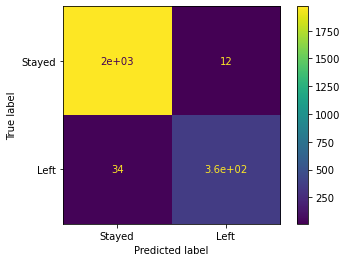

In [53]:
cm2= metrics.confusion_matrix(y_val, xgby_pred, labels=best_xgb.classes_)
disp2 = metrics.ConfusionMatrixDisplay(cm2, display_labels = ['Stayed', 'Left'])
disp2.plot()

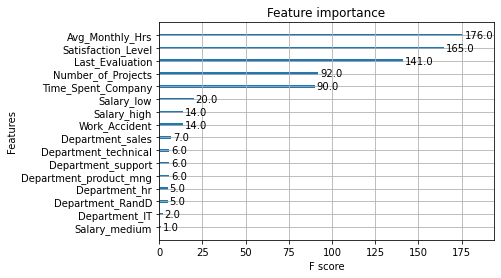

In [56]:
plot_importance(best_xgb)

In [57]:
table= pd.DataFrame({'Model_Name': ['BestRF', 'BestXGB'], 'Accuracy': [rf_acc, xgb_acc], 'Precision':[rf_precision, xgb_precision], 'Recall': [rf_recall, xgb_recall], 'F1': [rf_f1, xgb_f1]})
table

,Model_Name,Accuracy,Precision,Recall,F1
0,BestRF,0.981910,0.978320,0.911616,0.943791
1,BestXGB,0.980648,0.967914,0.914141,0.940260


In [58]:
best_xgb.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.2, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=4, max_leaves=0, min_child_weight=5,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, objective='binary:logistic',
              predictor='auto', random_state=55, reg_alpha=0, ...)

In [61]:
y_preds = best_xgb.predict(x_test)
accuracy= metrics.accuracy_score(y_test, y_preds)
recall=metrics.recall_score(y_test, y_preds)
precision= metrics.precision_score(y_test, y_preds)
f1 = metrics.f1_score(y_test, y_preds)
accuracy, recall, precision, f1

(0.983172065628944, 0.9355608591885441, 0.9679012345679012, 0.9514563106796116)

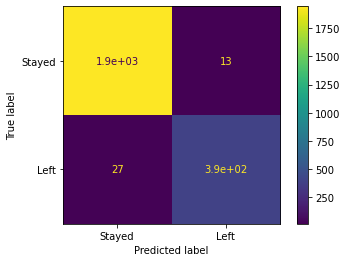

In [63]:
cm3= metrics.confusion_matrix(y_test, y_preds, labels=best_xgb.classes_)
disp3 = metrics.ConfusionMatrixDisplay(cm3, display_labels = ['Stayed', 'Left'])
disp3.plot()

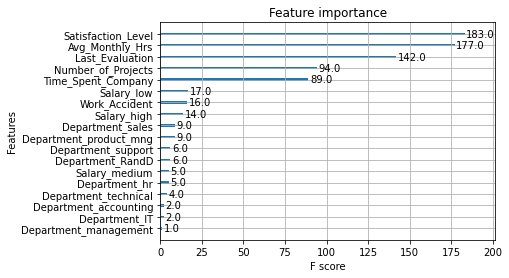

In [64]:
plot_importance(best_xgb)

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.
Correlation heatmaps showed the strongest indicators of whether an individual would leave the company were satisfaction level, time spent with the company, and whether or not there was a work related accident. However, both model tested showed the most important features to be quite different. The two models shared the same top 5 indicators with the champion model listing satisfaction, average hours, and last evaluation as the most important features followed by number of projects and time spent with the company.

Since satisfaction was the highest deciding factor looking at the correlations to satisfaction level showed a negative correlation with number of projects. While average hours didn't show much correlation with satisfaction there was a significant correlation with the number of projects. From that observation a recommended course of action would be to lighten project loads especially on those with the highest project counts and the most hours to prevent burnout.

The models used performed very well given the data presented with an accuracy score of 98.3% and a recall score of 93.6%. However, I do believe it would benefit from additional data such as more granular salary data, a count of the number of total promotions, time since last promotion, and additional performance review scores from prior evaluation.

Other questions that could be answered with this data and modeling are what factors contribute to an associate wanting to stay with the company long term. There were many observations of employees who had been with the company multiple degrees longer than the average, enough to be considered outliers. Taking a deeper look at the experiences of those worker and why they've stayed could provide valuable insight that could be applied towards increasing the amount of higher tenured staff. 

The data itself was presented in a fairly unbiased manner. If any ethical considerations were to be taken into account it would be that the highest tenured employees were removed from the data set. That would have the potential of biasing the data and modeling slightly towards younger associates since higher tenure comes with older age.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

Both models used to predict associate turnover showed the same top 5 factors that contributed the most to employees leaving the company. The features included satisfaction level, average hours, last evaluation score, number of projects, and time spent with the company. 

The champion mode (XGBoost) when fitted with the entire training set of data returned an accuracy score of 98.3% meaning 98.3% of predictions were correct. The same model also had a recall score of 93.6% showing that it correctly identified 93.6% of the employees who did leave the company. This model was chosen because of its slightly higher score in recall because falsely identifying an associate as staying is more costly than falsely identifying a potential exit. Precision and F1 score were the other metrics used returning vales of 96.8% and 95.1% respectively.

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

Through machine learning models we were able to discover the primary factors that influence associate turnover based on the data that was given. The data shows satisfaction level, average hours, and last evaluation score were the most prominent features in determining whether an associate would leave the company. 

Extrapolating the correlations to the highest feature importances we can conclude that lightening project workload would positively impact satisfaction level while also slightly reducing hours. These improvements would be a great start to improving retention rates. 

The current model has shown strong predictive power in classifying which associates are more likely to leave, and could be used to identify employees that may be getting close to a departure. By focusing resources on providing a more satisfying work environment for the associates that were incorrectly identified as leaving, turnover can be actively prevented for the highest risk workers. Additional data could make the model even more robust and better at predicting this classification such as including specific pay, number of promotions, and other previous evaluation data.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.